In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [17]:
df = pd.read_csv('SteelPlatesFaults.csv')
df.shape

(1941, 34)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empt

In [19]:
df.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


In [20]:
df.describe().round(2)

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
count,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,...,1941.00,1941.00,1941.00,1941.00,1941.0,1941.0,1941.00,1941.00,1941.00,1941.00
mean,571.14,617.96,1650684.87,1650738.71,1893.88,111.86,82.97,206312.15,84.55,130.19,...,0.08,-0.13,0.59,0.08,0.1,0.2,0.04,0.03,0.21,0.35
std,520.69,497.63,1774578.41,1774590.09,5168.46,301.21,426.48,512293.59,32.13,18.69,...,0.50,0.15,0.34,0.27,0.3,0.4,0.19,0.17,0.41,0.48
min,0.00,4.00,6712.00,6724.00,2.00,2.00,1.00,250.00,0.00,37.00,...,-0.99,-1.00,0.12,0.00,0.0,0.0,0.00,0.00,0.00,0.00
25%,51.00,192.00,471253.00,471281.00,84.00,15.00,13.00,9522.00,63.00,124.00,...,-0.33,-0.20,0.25,0.00,0.0,0.0,0.00,0.00,0.00,0.00
50%,435.00,467.00,1204128.00,1204136.00,174.00,26.00,25.00,19202.00,90.00,127.00,...,0.10,-0.13,0.51,0.00,0.0,0.0,0.00,0.00,0.00,0.00
75%,1053.00,1072.00,2183073.00,2183084.00,822.00,84.00,83.00,83011.00,106.00,140.00,...,0.51,-0.07,1.00,0.00,0.0,0.0,0.00,0.00,0.00,1.00
max,1705.00,1713.00,12987661.00,12987692.00,152655.00,10449.00,18152.00,11591414.00,203.00,253.00,...,0.99,0.64,1.00,1.00,1.0,1.0,1.00,1.00,1.00,1.00


In [21]:
df.isnull().sum()

,0
X_Minimum,0
X_Maximum,0
Y_Minimum,0
Y_Maximum,0
Pixels_Areas,0
X_Perimeter,0
Y_Perimeter,0
Sum_of_Luminosity,0
Minimum_of_Luminosity,0
Maximum_of_Luminosity,0


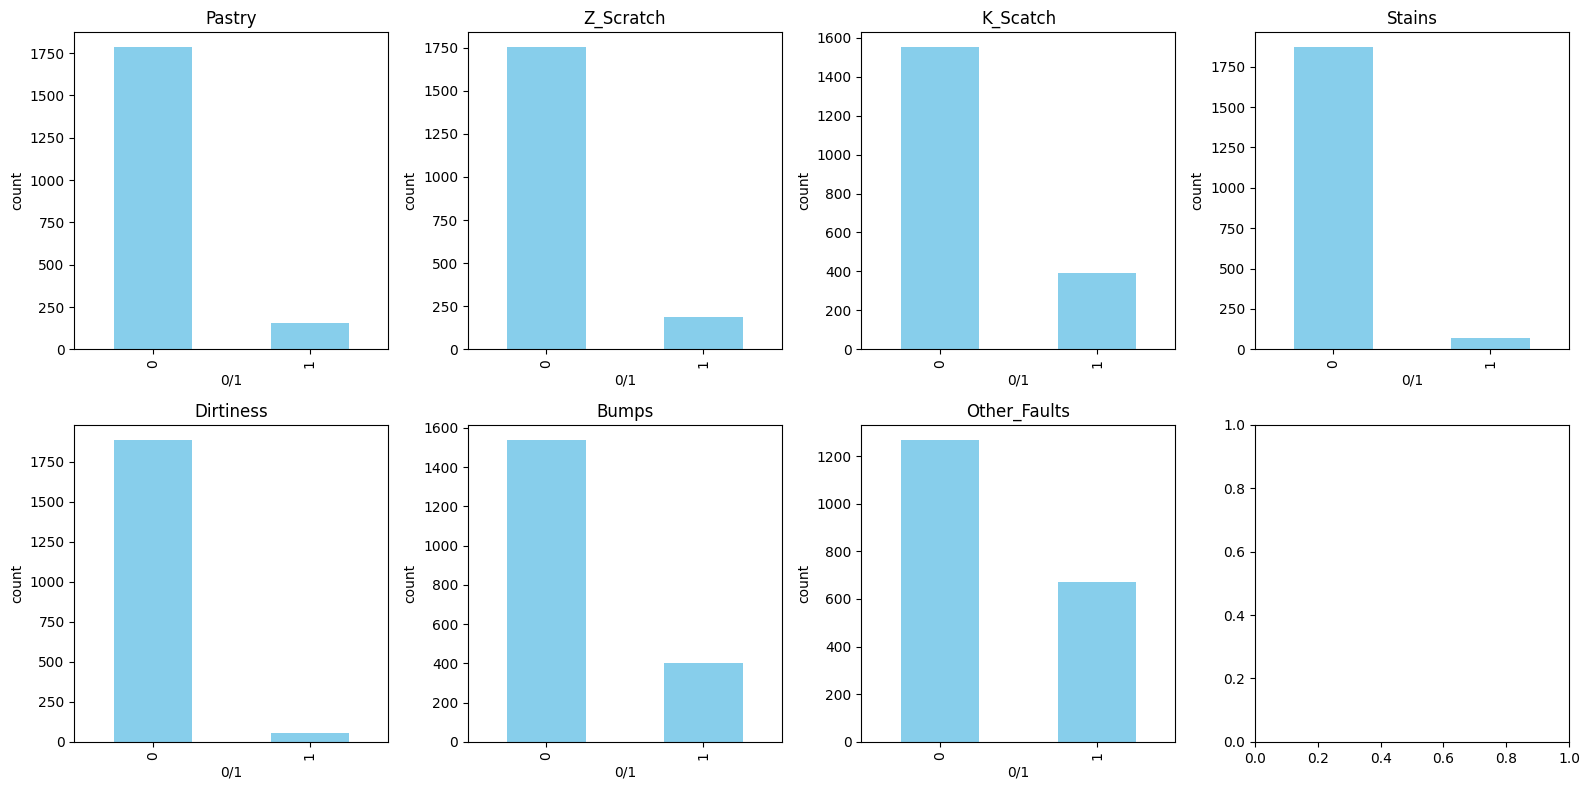

In [22]:
target_cols = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(target_cols):
    df[col].value_counts().plot.bar(ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('0/1')
    axes[i].set_ylabel('count')
plt.tight_layout()
plt.show()

Виден дисбаланс классов, целых тарелок больше поврежденных

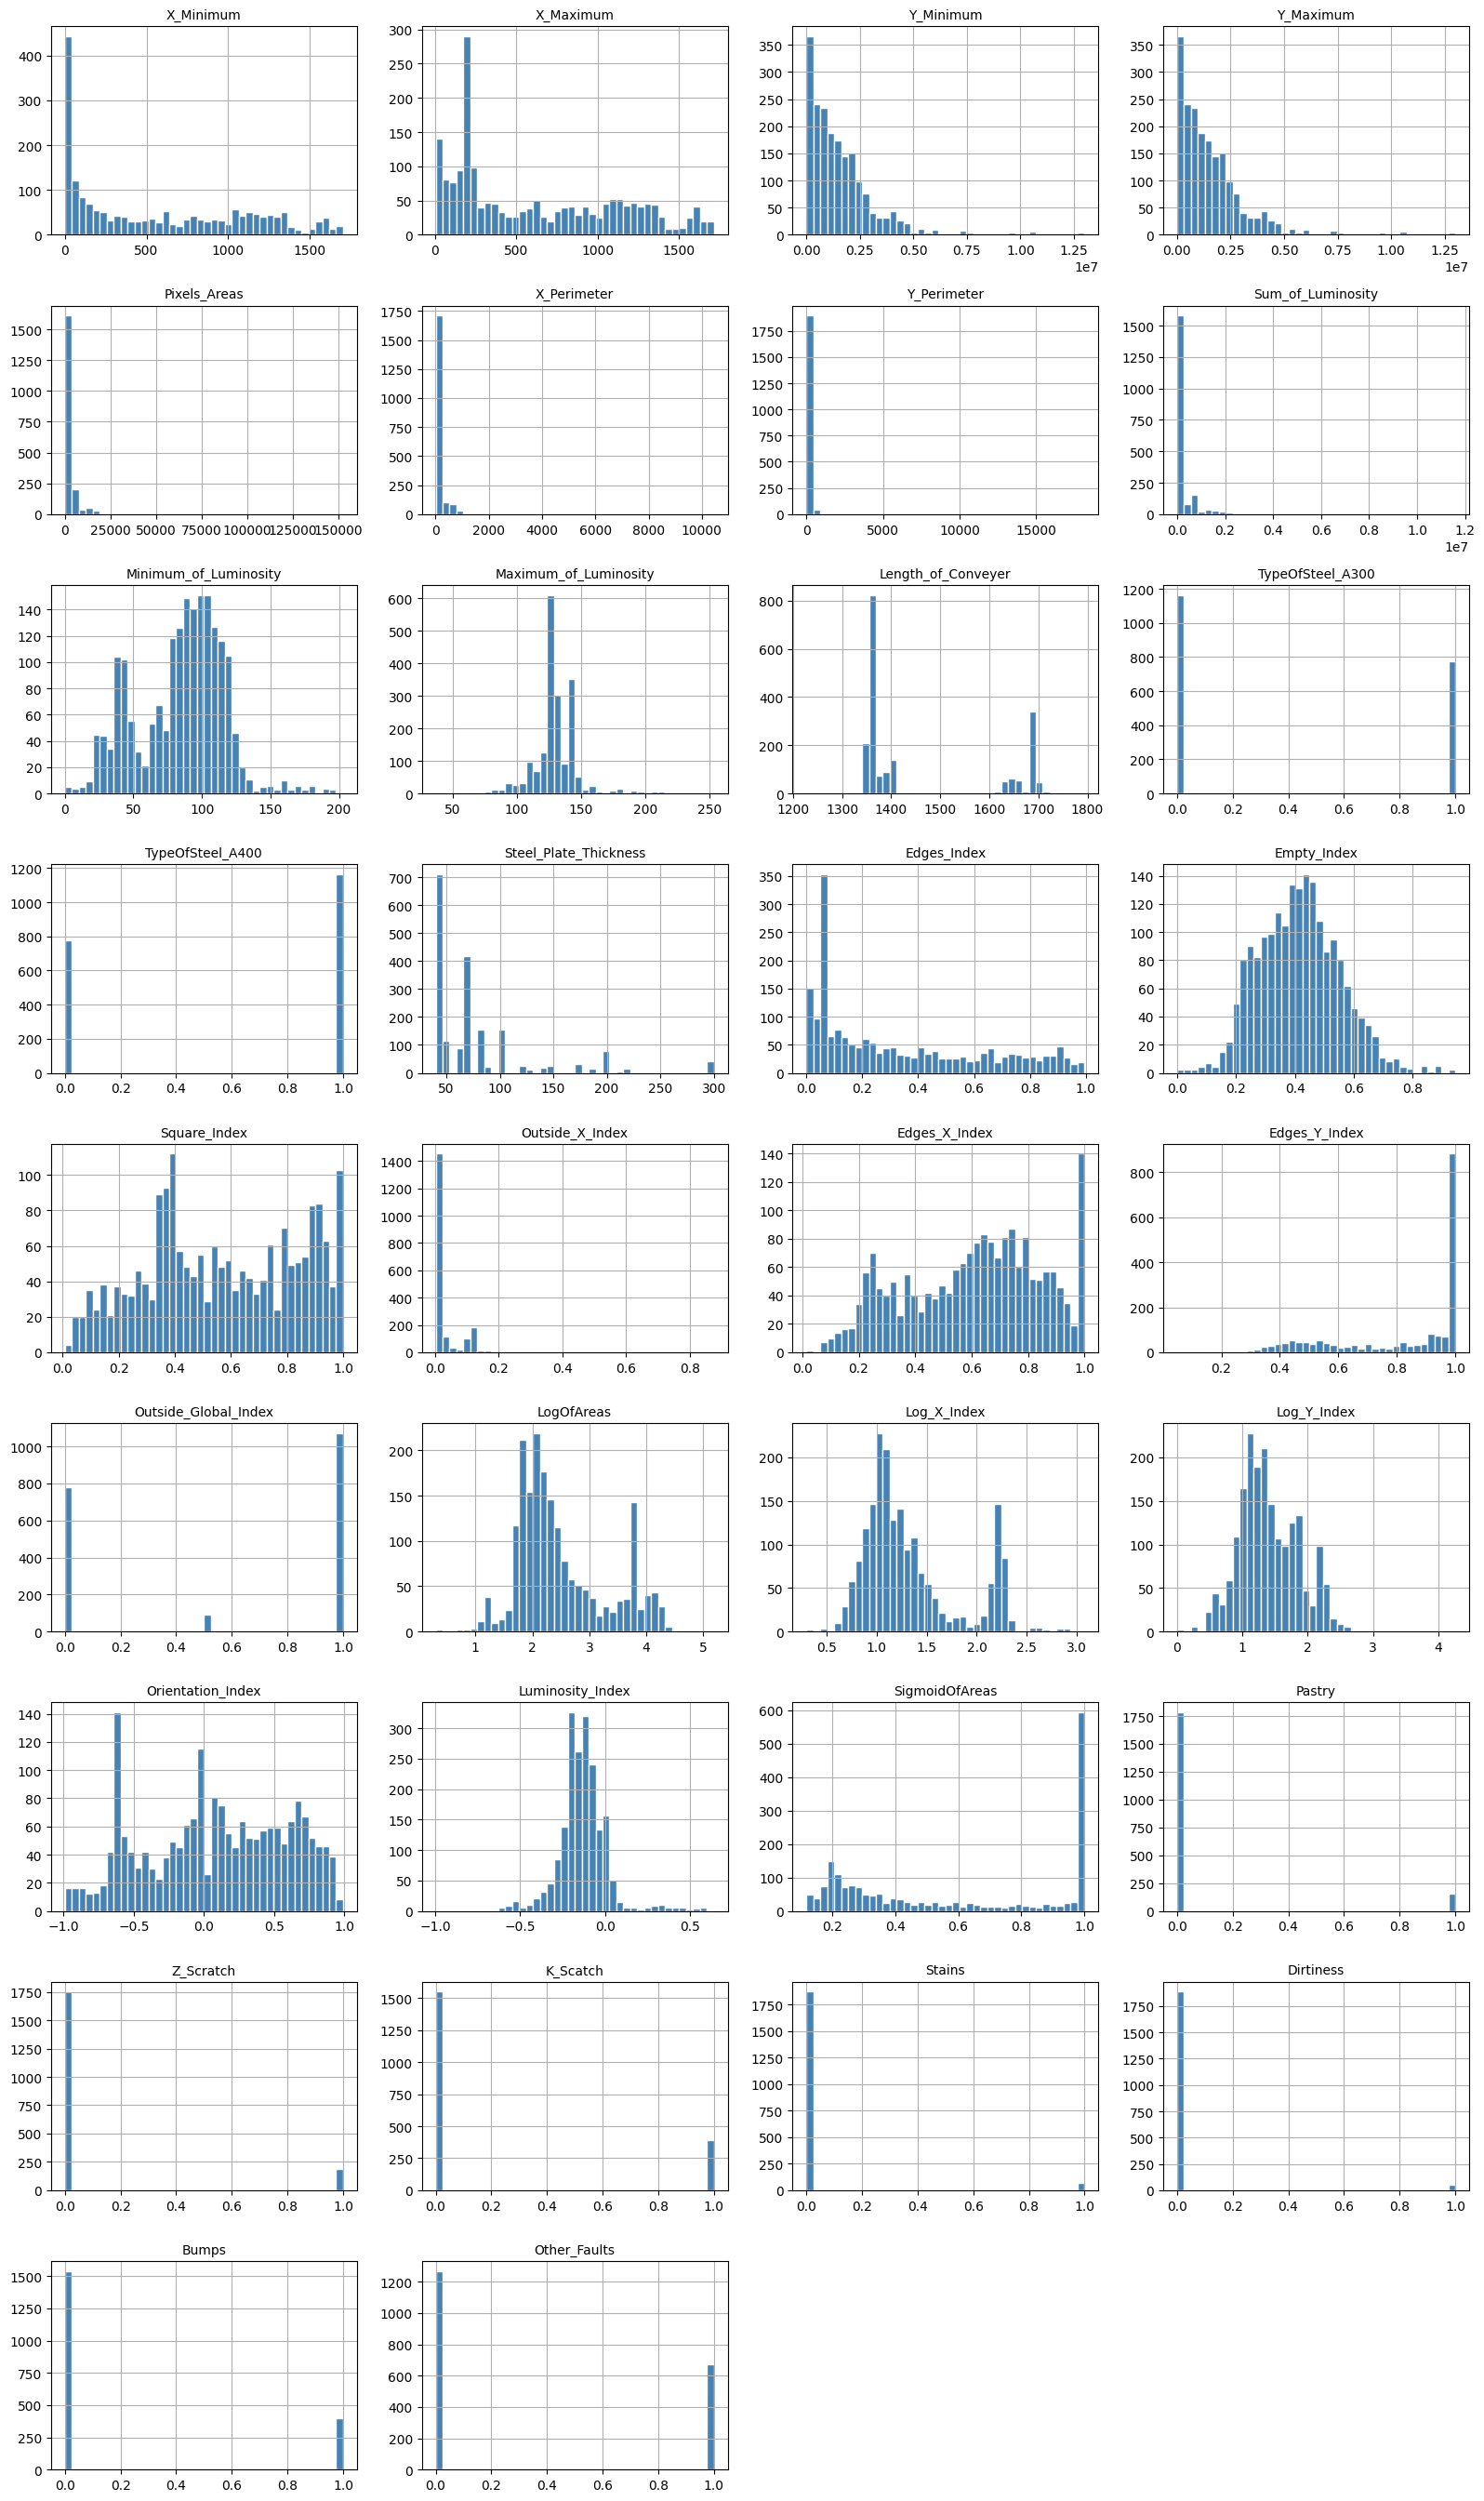

In [23]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

У Pixels_Areas, X_Perimeter, Y_Perimeter, Sum_of_Luminosity есть выбросы, удалим их

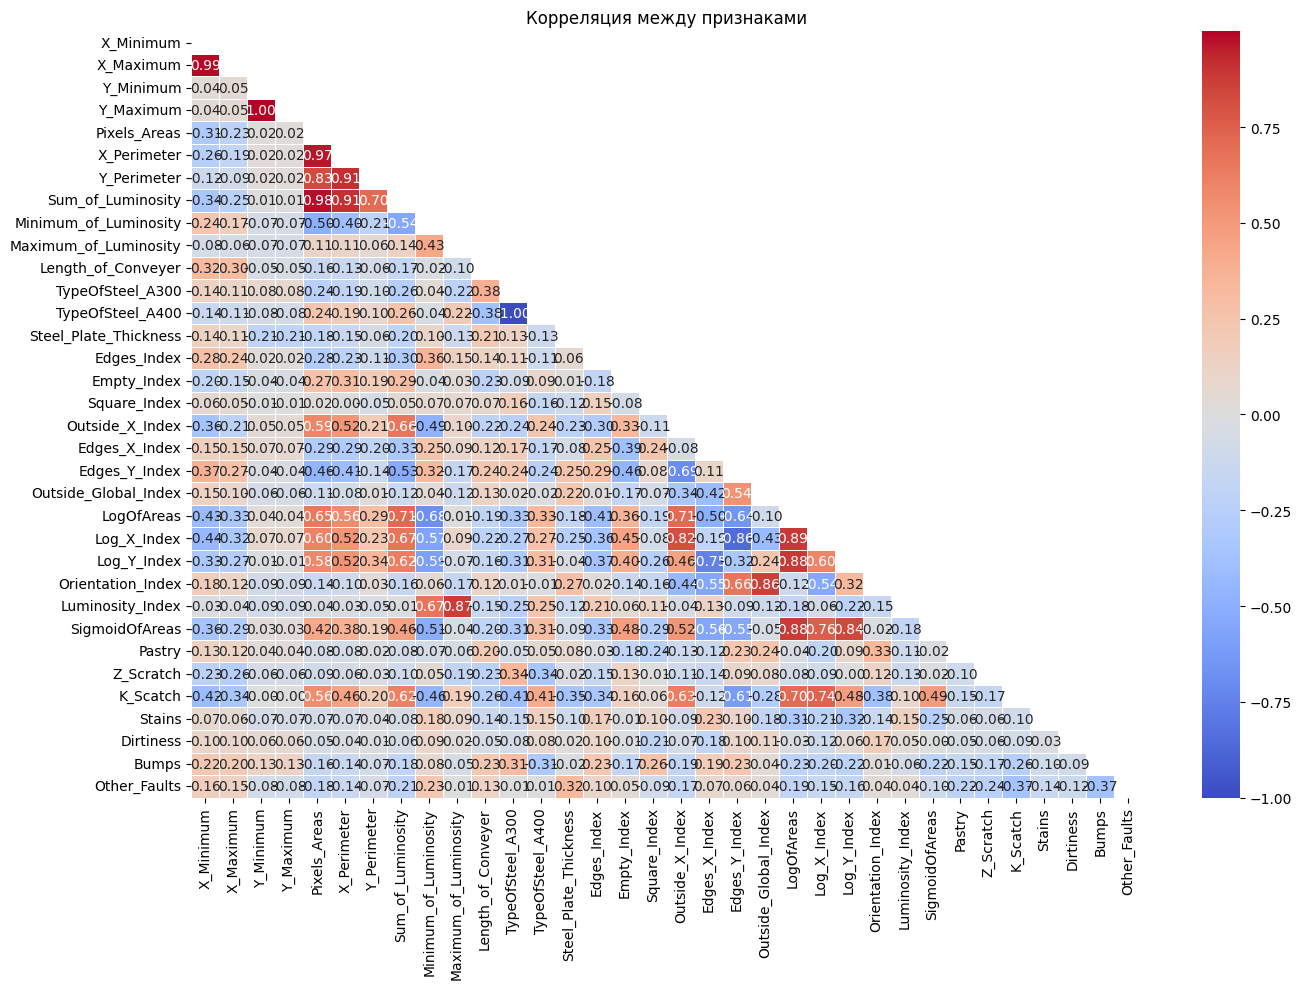

In [24]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

In [25]:
from sklearn.model_selection import train_test_split

target_cols = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
X = df.drop(columns=target_cols)
y = df[target_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
cols_to_drop = [
    'Log_X_Index', 'Log_Y_Index',
    'X_Maximum', 'Y_Maximum',
]

X_train_reduced = X_train.drop(columns=cols_to_drop)
X_test_reduced = X_test.drop(columns=cols_to_drop)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, hamming_loss

lr = MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42))
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


print("Логистическая регрессия")
print(f"macro F1: {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"micro F1: {f1_score(y_test, y_pred_lr, average='micro'):.4f}")
print(f"Hamming Loss: {hamming_loss(y_test, y_pred_lr):.4f}")

print("\nСлучайный лес")
print(f"macro F1: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"micro F1: {f1_score(y_test, y_pred_rf, average='micro'):.4f}")
print(f"Hamming Loss: {hamming_loss(y_test, y_pred_rf):.4f}")

Логистическая регрессия
macro F1: 0.6667
micro F1: 0.6946
Hamming Loss: 0.0775

Случайный лес
macro F1: 0.7485
micro F1: 0.7583
Hamming Loss: 0.0613


Гипотеза 1 подтвердилась. У RandomForest macro F1 = 0.7485,а у LogReg 0.6667.  Случайный лес лучше улавливает нелинейные зависимости

In [32]:
from sklearn.model_selection import cross_val_score

lr_cv = MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42))
scores_lr = cross_val_score(lr_cv, X_train_scaled, y_train, cv=5, scoring='f1_macro')
print(f"LogReg CV macro F1: {scores_lr.mean():.4f}")

rf_cv = RandomForestClassifier(n_estimators=100, random_state=42)
scores_rf = cross_val_score(rf_cv, X_train, y_train, cv=5, scoring='f1_macro')
print(f"RF CV macro F1: {scores_rf.mean():.4f} ")

LogReg CV macro F1: 0.6642
RF CV macro F1: 0.7474 


In [34]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'estimator__C': [0.01, 0.1, 1, 10],
    'estimator__penalty': ['l1', 'l2'],
    'estimator__solver': ['liblinear']
}

grid_lr = GridSearchCV(
    MultiOutputClassifier(LogisticRegression(max_iter=1000)),
    param_grid_lr,
    cv=5,
    scoring='f1_macro'
)
grid_lr.fit(X_train_scaled, y_train)

print("Лучшие параметры LogReg:", grid_lr.best_params_)
print("Лучший CV f1_macro:", grid_lr.best_score_)


param_grid_rf = {
    'max_depth': [5, 10, 15, 20, None],
    'n_estimators': [50, 100, 200]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1_macro'
)
grid_rf.fit(X_train, y_train)

print("Лучшие параметры RF:", grid_rf.best_params_)
print("Лучший CV f1_macro:", grid_rf.best_score_)

Лучшие параметры LogReg: {'estimator__C': 10, 'estimator__penalty': 'l1', 'estimator__solver': 'liblinear'}
Лучший CV f1_macro: 0.6669306665015079
Лучшие параметры RF: {'max_depth': 20, 'n_estimators': 100}
Лучший CV f1_macro: 0.7550448702435967


Гипотеза 5 подтвердилась. GridSearch выбрал L1 регуляризациюкак самую лучшую


Гипотеза 6 не подтвердилась. Наилучшей оказалась глубина 20